# Sales Prediction using Python
CodeAlpha Data Science Internship

This notebook predicts product sales based on advertising spend across TV, Radio, and Newspaper channels.

## 1. Load and Explore the Dataset

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('../data/advertising.csv')
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [2]:
df.info()
print()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB



,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


In [3]:
print("Missing values:\n", df.isnull().sum())

Missing values:
 TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64


## 2. Exploratory Data Analysis

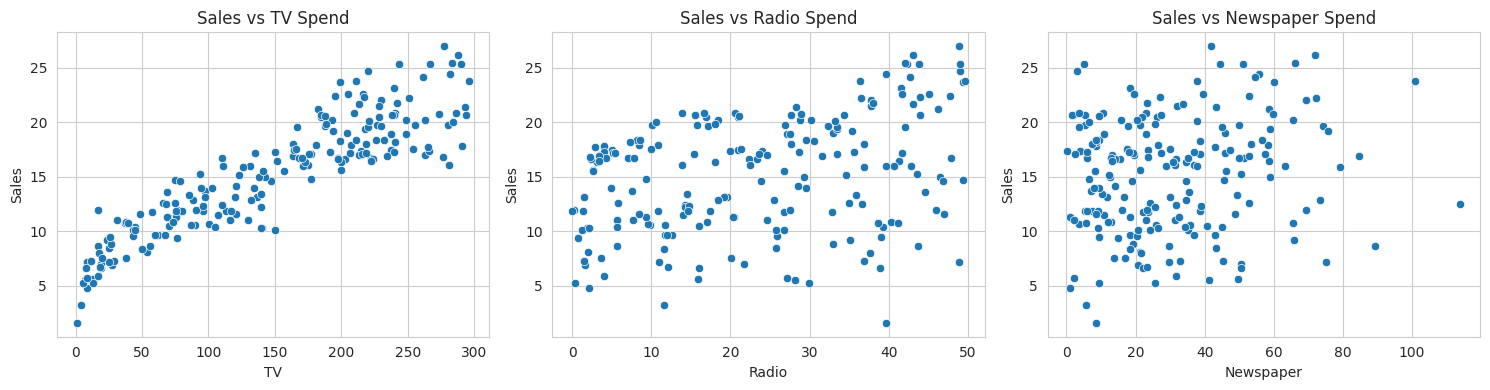

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, ['TV', 'Radio', 'Newspaper']):
    sns.scatterplot(data=df, x=col, y='Sales', ax=ax)
    ax.set_title(f'Sales vs {col} Spend')

plt.tight_layout()
plt.savefig('../images/sales_vs_channels.png', dpi=150)
plt.show()

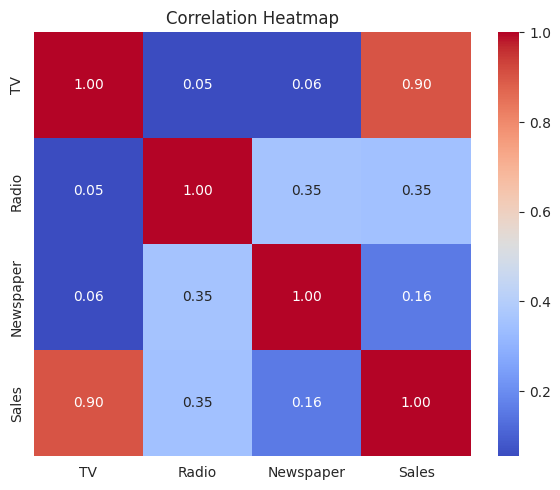

In [5]:
plt.figure(figsize=(6, 5))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig('../images/correlation_heatmap.png', dpi=150)
plt.show()

### Observation
The correlation heatmap and scatter plots already hint at which channels matter most — TV and Radio show a much stronger relationship with Sales than Newspaper does.

## 3. Train/Test Split

In [6]:
from sklearn.model_selection import train_test_split

X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (160, 3)
Test shape: (40, 3)
